In [1]:
import os

# Pastas Principais
base_dir = 'wikiart_dataset'
train_dir = os.path.join(base_dir, 'train')
validation_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

# Ordenar Classes
classes_desordenadas = os.listdir(train_dir)
classes = sorted(classes_desordenadas)

print("Contagem de Imagens por Pasta e Classe:\n")
print(f"{'Classe':<23} | {'Treino':<8} | {'Validação':<10} | {'Teste':<8}")
print("-" * 56)

total_treino = 0
total_validacao = 0
total_teste = 0

for c in classes:
    
    pasta_treino_classe = os.path.join(train_dir, c)
    pasta_val_classe = os.path.join(validation_dir, c)
    pasta_teste_classe = os.path.join(test_dir, c)
    
    train_count = len(os.listdir(pasta_treino_classe))
    val_count = len(os.listdir(pasta_val_classe))
    test_count = len(os.listdir(pasta_teste_classe))
    
    total_treino = total_treino + train_count
    total_validacao = total_validacao + val_count
    total_teste = total_teste + test_count
    
    print(f"{c:<23} | {train_count:<8} | {val_count:<10} | {test_count:<8}")

print("-" * 56)

print("\nTotal Treino:    ", total_treino)
print("Total Validação: ", total_validacao)
print("Total Teste:     ", total_teste)

Contagem de Imagens por Pasta e Classe:

Classe                  | Treino   | Validação  | Teste   
--------------------------------------------------------
Abstract Expressionism  | 1500     | 500        | 500     
Art Nouveau (Modern)    | 1500     | 500        | 500     
Baroque                 | 1500     | 500        | 500     
Cubism                  | 1500     | 500        | 500     
Expressionism           | 1500     | 500        | 500     
Impressionism           | 1500     | 500        | 500     
Neoclassicism           | 1500     | 500        | 500     
Northern Renaissance    | 1500     | 500        | 500     
Pop Art                 | 1500     | 500        | 500     
Post-Impressionism      | 1500     | 500        | 500     
Realism                 | 1500     | 500        | 500     
Rococo                  | 1500     | 500        | 500     
Romanticism             | 1500     | 500        | 500     
Surrealism              | 1500     | 500        | 500     
Symbolism        

In [3]:
from keras.utils import image_dataset_from_directory

IMG_SIZE = 224
BATCH_SIZE = 32

train_dataset = image_dataset_from_directory(
    train_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    # Ativa o One-Hot Encoding (obrigatório para classificar 15 classes mutuamente exclusivas)
    label_mode='categorical'
)

validation_dataset = image_dataset_from_directory(
    validation_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_dataset = image_dataset_from_directory(
    test_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

Found 22500 files belonging to 15 classes.
Found 7500 files belonging to 15 classes.
Found 7500 files belonging to 15 classes.


In [4]:
for data_batch, labels_batch in train_dataset:
    print("Verificação do Formato dos Dados:")
    print(f"Batch de Imagens:   {data_batch.shape} -> [Tamanho do Batch, Altura, Largura, Canais RGB]")
    print(f"Batch de Etiquetas: {labels_batch.shape} -> [Tamanho do Batch, Número de Classes]")
    break

Verificação do Formato dos Dados:
Batch de Imagens:   (32, 224, 224, 3) -> [Tamanho do Batch, Altura, Largura, Canais RGB]
Batch de Etiquetas: (32, 15) -> [Tamanho do Batch, Número de Classes]


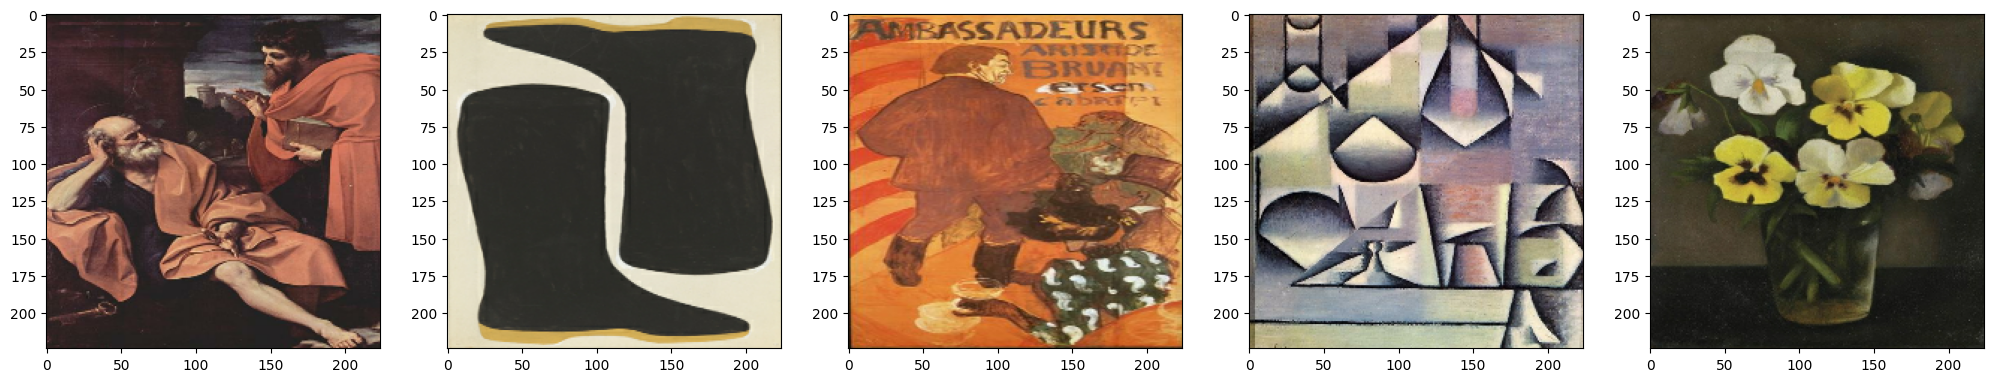

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 5, figsize=(25, 5))

for data_batch, _ in train_dataset.take(1):
    for i in range(5):

        axes[i].imshow(data_batch[i].numpy().astype("uint8"))
plt.show()

In [6]:
from tensorflow import keras
from keras import layers
from keras import models

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(1./255)(inputs)

x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)
x = layers.Dense(512, activation="relu")(x)

outputs = layers.Dense(15, activation="softmax")(x)

model = keras.Model(inputs=inputs, outputs=outputs)

In [7]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,686,223 (36.95 MB)

 Trainable params: 9,686,223 (36.95 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
import tensorflow as tf

model.compile(loss='categorical_crossentropy', optimizer=tf.keras.optimizers.RMSprop(learning_rate=1e-4), metrics=['accuracy', tf.keras.metrics.Precision(name='precision'),tf.keras.metrics.Recall(name='recall')])

In [9]:
print("Treino do modelo:")
history = model.fit(train_dataset,epochs=30,validation_data=validation_dataset)

Treino do modelo:
Epoch 1/30


I0000 00:00:1780008345.255462  121025 service.cc:153] XLA service 0x7318700327d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780008345.255541  121025 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4070 SUPER, Compute Capability 8.9 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1780008345.333704  121025 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780008345.535887  121025 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1780008345.556614  121025 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2049__.56


  2/704 ━━━━━━━━━━━━━━━━━━━━ 1:02 89ms/step - accuracy: 0.1328 - loss: 2.7068 - precision: 0.0000e+00 - recall: 0.0000e+00 

I0000 00:00:1780008352.122393  121025 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


226/704 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.0946 - loss: 2.6826 - precision: 0.1288 - recall: 1.9606e-04

...

704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9923 - loss: 0.0279 - precision: 0.9927 - recall: 0.9917 - val_accuracy: 0.2815 - val_loss: 7.9041 - val_precision: 0.2901 - val_recall: 0.2741
Epoch 30/30
255/704 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 0.9920 - loss: 0.0296 - precision: 0.9930 - recall: 0.9915

W0000 00:00:1780009021.179019  126719 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


702/704 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9910 - loss: 0.0319 - precision: 0.9918 - recall: 0.9905

W0000 00:00:1780009034.202489  126805 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


704/704 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.9905 - loss: 0.0334 - precision: 0.9911 - recall: 0.9900 - val_accuracy: 0.2719 - val_loss: 9.2288 - val_precision: 0.2770 - val_recall: 0.2637


In [10]:
model.save('models/model_s.keras')

In [11]:
print("Avaliação do Modelo no Conjunto de Validção:")

val_loss, val_acc, val_precision, val_recall = model.evaluate(validation_dataset)

print("\nResultados Validação:")
print(f"Loss:        {val_loss:.4f}")
print(f"Accuracy:    {val_acc:.4f}")
print(f"Precision:   {val_precision:.4f}")
print(f"Recall:      {val_recall:.4f}")

Avaliação do Modelo no Conjunto de Validção:
146/235 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2697 - loss: 9.2246 - precision: 0.2758 - recall: 0.2625

W0000 00:00:1780009061.632320  126934 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.2719 - loss: 9.2288 - precision: 0.2770 - recall: 0.2637

Resultados Validação:
Loss:        9.2288
Accuracy:    0.2719
Precision:   0.2770
Recall:      0.2637


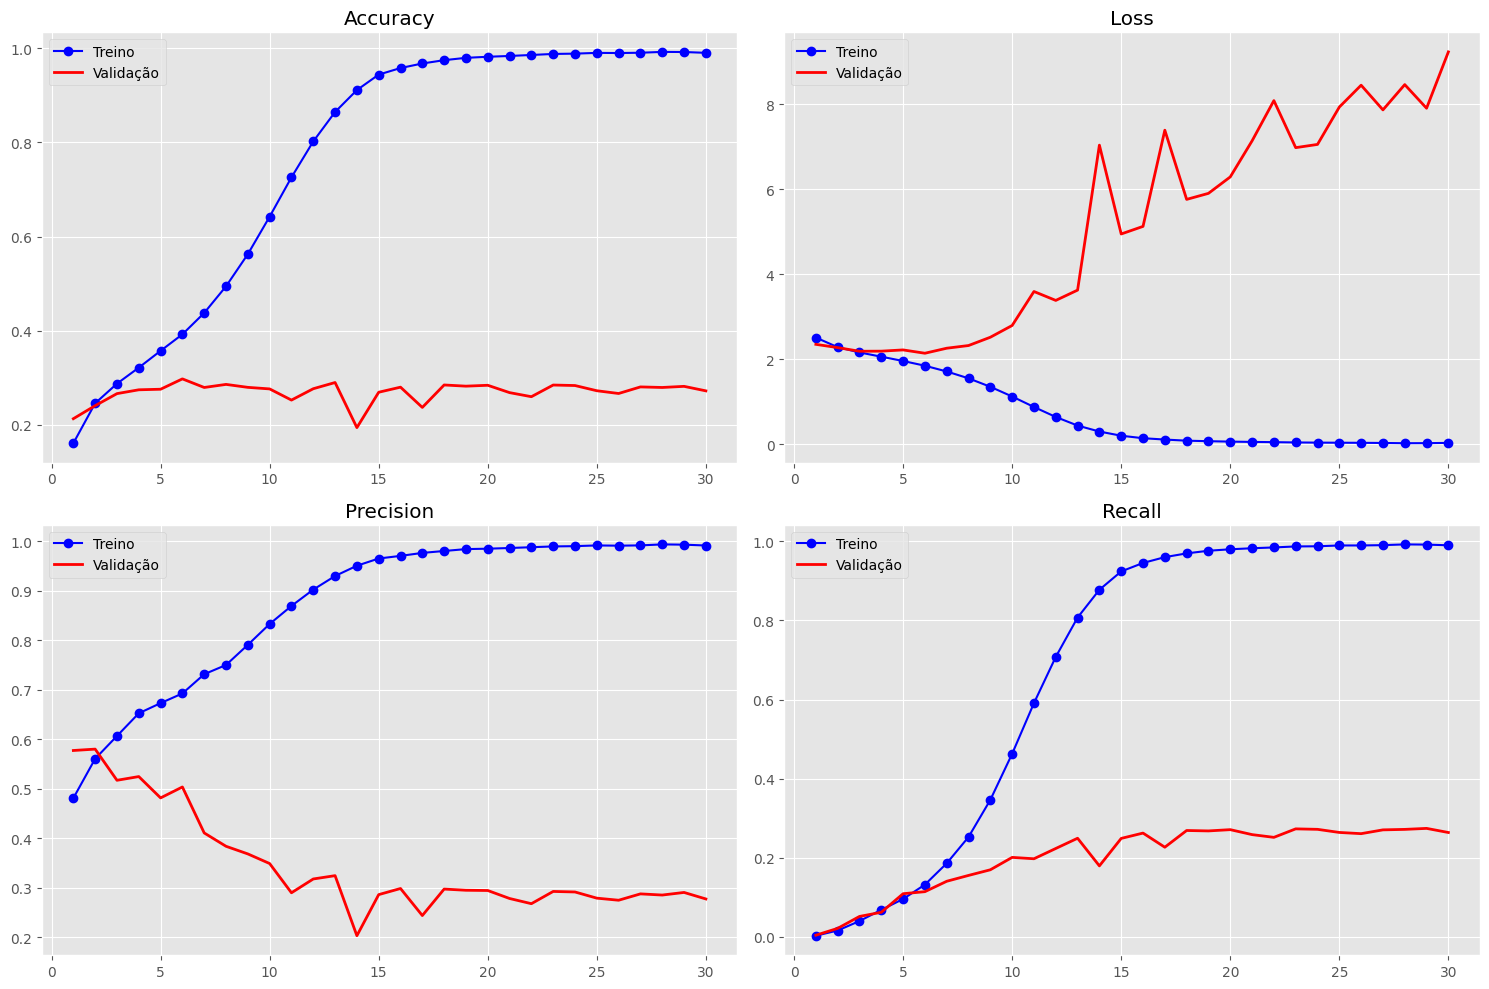

In [12]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

precision = history.history['precision']
val_precision = history.history['val_precision']
recall = history.history['recall']
val_recall = history.history['val_recall']

epochs = range(1, len(acc) + 1)

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

axs[0, 0].plot(epochs, acc, 'bo-', label='Treino')
axs[0, 0].plot(epochs, val_acc, 'r-', linewidth=2, label='Validação')
axs[0, 0].set_title('Accuracy')
axs[0, 0].legend()

axs[0, 1].plot(epochs, loss, 'bo-', label='Treino')
axs[0, 1].plot(epochs, val_loss, 'r-', linewidth=2, label='Validação')
axs[0, 1].set_title('Loss')
axs[0, 1].legend()

axs[1, 0].plot(epochs, precision, 'bo-', label='Treino')
axs[1, 0].plot(epochs, val_precision, 'r-', linewidth=2, label='Validação')
axs[1, 0].set_title('Precision')
axs[1, 0].legend()

axs[1, 1].plot(epochs, recall, 'bo-', label='Treino')
axs[1, 1].plot(epochs, val_recall, 'r-', linewidth=2, label='Validação')
axs[1, 1].set_title('Recall')
axs[1, 1].legend()

plt.tight_layout()
plt.show()

Found 7500 files belonging to 15 classes.
 25/235 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step

W0000 00:00:1780009182.951453  127381 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


W0000 00:00:1780009185.892063  127455 png_io.cc:96] PNG warning: iCCP: known incorrect sRGB profile


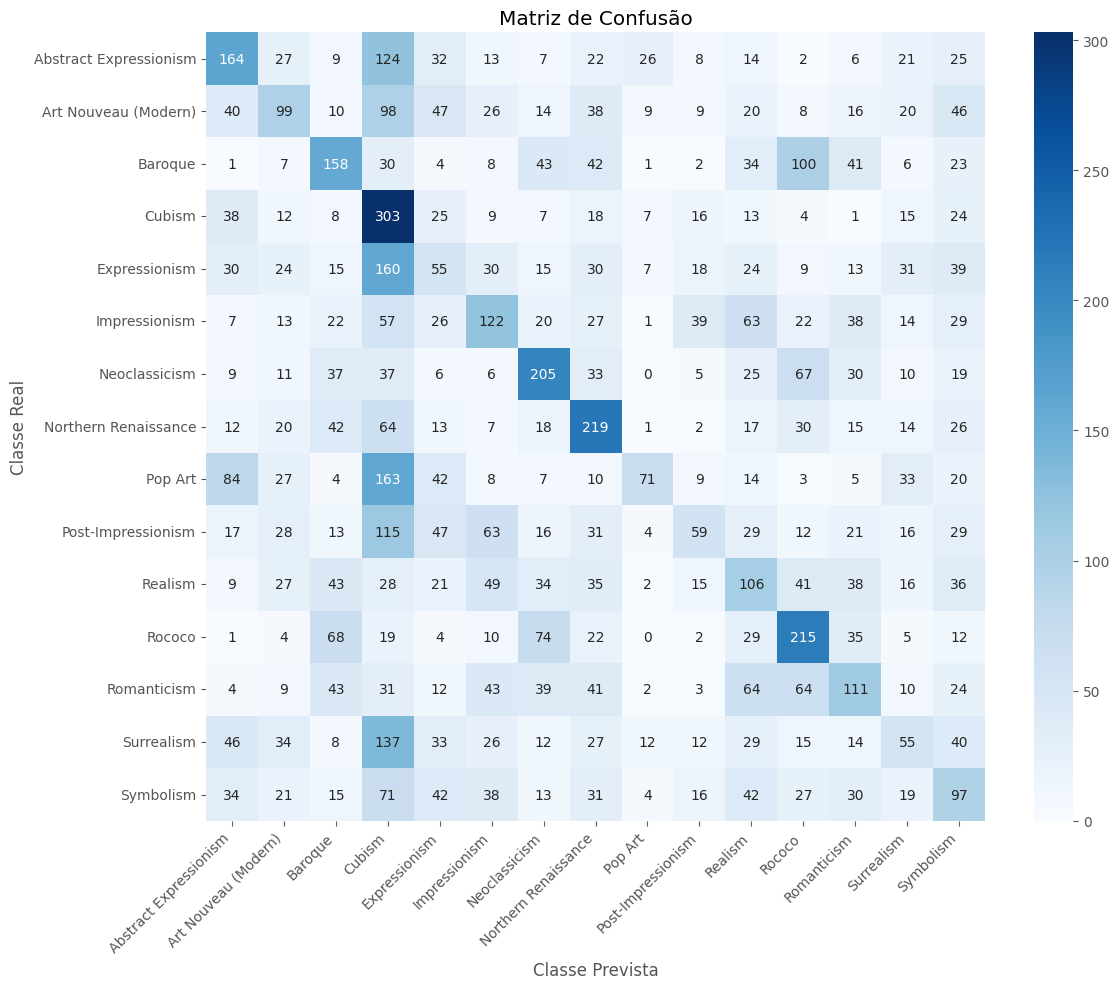

In [13]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Para a Matriz de Confusão, precisamos garantir que as previsões e as etiquetas reais estejam na mesma ordem. Por isso, criamos um dataset de validação sem shuffle.
validation_dataset_unshuffled = image_dataset_from_directory(validation_dir, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE, label_mode='categorical', shuffle=False)

previsoes = model.predict(validation_dataset_unshuffled)
previsoes_classes = np.argmax(previsoes, axis=1)

etiquetas_reais = np.concatenate([y for x, y in validation_dataset_unshuffled], axis=0)
etiquetas_reais_classes = np.argmax(etiquetas_reais, axis=1)

cm = confusion_matrix(etiquetas_reais_classes, previsoes_classes)
nomes_classes = validation_dataset_unshuffled.class_names

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nomes_classes, yticklabels=nomes_classes)

plt.title('Matriz de Confusão')
plt.ylabel('Classe Real')
plt.xlabel('Classe Prevista')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [14]:
from sklearn.metrics import classification_report

print("\nRelatório Detalhado de Classificação:")
# Tabela com Precision, Recall e F1-Score para cada classe
relatorio = classification_report(
    etiquetas_reais_classes, 
    previsoes_classes, 
    target_names=nomes_classes
)

print(relatorio)


Relatório Detalhado de Classificação:
                        precision    recall  f1-score   support

Abstract Expressionism       0.33      0.33      0.33       500
  Art Nouveau (Modern)       0.27      0.20      0.23       500
               Baroque       0.32      0.32      0.32       500
                Cubism       0.21      0.61      0.31       500
         Expressionism       0.13      0.11      0.12       500
         Impressionism       0.27      0.24      0.25       500
         Neoclassicism       0.39      0.41      0.40       500
  Northern Renaissance       0.35      0.44      0.39       500
               Pop Art       0.48      0.14      0.22       500
    Post-Impressionism       0.27      0.12      0.17       500
               Realism       0.20      0.21      0.21       500
                Rococo       0.35      0.43      0.38       500
           Romanticism       0.27      0.22      0.24       500
            Surrealism       0.19      0.11      0.14       500


O MODELO ESTÁ EM OVERFITTING